# Evaluation of a structure of samples from models on 60km -> 2.2km-4x over Birmingham

In [ ]:
%reload_ext autoreload

%autoreload 2

%reload_ext dotenv
%dotenv

In [ ]:
from mlde_analysis.default_params import *

In [ ]:
# Parameters
desc = "Comparison of diffusion model for CPMGEM-pr paper\nTest split\n12em dataset and models, 60km inputs -> 8.8km outputs, pSTV input variable set\nCompare techniques: diffusion, u-net, bilinear\n"
eval_vars = ["pr"]
derived_variables_config = {}
dataset_configs = {
    "CPM": "bham64_ccpm-4x_12em_psl-sphum4th-temp4th-vort4th_pr",
    "GCM": "bham64_gcm-4x_12em_psl-sphum4th-temp4th-vort4th_pr",
}
split = "test"
ensemble_members = [
    "01",
    "04",
    "05",
    "06",
    "07",
    "08",
    "09",
    "10",
    "11",
    "12",
    "13",
    "15",
]
samples_per_run = 6
sample_configs = {
    "CPM": [
        {
            "label": "CPMGEM_cCPM",
            "sample_specs": [
                {
                    "fq_model_id": "score-sde/subvpsde/ukcp_local_pr_12em_cncsnpp_continuous/bham-4x_12em_pSTV",
                    "checkpoint": "epoch_20",
                    "input_xfm": "bham64_ccpm-4x_12em_psl-sphum4th-temp4th-vort4th_pr-stan",
                    "dataset": "bham64_ccpm-4x_12em_psl-sphum4th-temp4th-vort4th_pr",
                    "variables": ["pr"],
                }
            ],
            "deterministic": False,
            "CCS": True,
            "color": "tab:blue",
            "order": 11,
        },
        {
            "label": "U-Net_cCPM",
            "sample_specs": [
                {
                    "fq_model_id": "score-sde/deterministic/ukcp_local_pr_12em_plain_unet/bham_pSTV-ema-gradcl-256-batch",
                    "checkpoint": "epoch_100",
                    "input_xfm": "bham64_ccpm-4x_12em_psl-sphum4th-temp4th-vort4th_pr-stan",
                    "dataset": "bham64_ccpm-4x_12em_psl-sphum4th-temp4th-vort4th_pr",
                    "variables": ["pr"],
                }
            ],
            "deterministic": True,
            "color": "tab:orange",
            "order": 2,
        },
        {
            "label": "BCSD_cCPM",
            "sample_specs": [
                {
                    "fq_model_id": "bcsd-v1/ukcp_local_pr_12em-ws3",
                    "checkpoint": "epoch-0",
                    "input_xfm": "bham64_ccpm-4x_12em_linpr_pr-bcsd",
                    "dataset": "bham64_ccpm-4x_12em_linpr_pr",
                    "variables": ["pr"],
                }
            ],
            "deterministic": True,
            "color": "tab:red",
            "order": 1,
            "UQ": True,
            "CCS": True,
        },
    ],
    "GCM": [
        {
            "label": "CPMGEM_GCM",
            "sample_specs": [
                {
                    "fq_model_id": "score-sde/subvpsde/ukcp_local_pr_12em_cncsnpp_continuous/bham-4x_12em_pSTV",
                    "checkpoint": "epoch_20",
                    "input_xfm": "bham64_gcm-4x_12em_psl-sphum4th-temp4th-vort4th_pr-pixelmmsstan",
                    "dataset": "bham64_gcm-4x_12em_psl-sphum4th-temp4th-vort4th_pr",
                    "variables": ["pr"],
                }
            ],
            "deterministic": False,
            "CCS": True,
            "UQ": False,
            "color": "tab:green",
            "order": 20,
        }
    ],
}
sample_configs_at_60km = [
    {
        "label": "CPMGEM_GCM@60km",
        "sample_specs": [
            {
                "fq_model_id": "score-sde/subvpsde/ukcp_local_pr_12em_cncsnpp_continuous/bham-4x_12em_pSTV/postprocess/gcm-grid",
                "checkpoint": "epoch_20",
                "input_xfm": "bham64_gcm-4x_12em_psl-sphum4th-temp4th-vort4th_pr-pixelmmsstan",
                "dataset": "bham64_gcm-4x_12em_psl-sphum4th-temp4th-vort4th_pr",
                "variables": ["pr"],
            }
        ],
        "deterministic": False,
    }
]
dataset_configs_at_60km = {
    "CPM": "bham64_ccpm-60km_12em_pr_pr",
    "GCM": "bham64_gcm-60km_12em_rawpr_pr",
}
example_percentiles = {
    "CPM": {
        "DJF Wet": {"percentile": 0.8, "variable": "pr", "season": "DJF"},
        "DJF Wettest": {"percentile": 1, "variable": "pr", "season": "DJF"},
        "JJA Wet": {"percentile": 0.8, "variable": "pr", "season": "JJA"},
        "JJA Wettest": {"percentile": 1, "variable": "pr", "season": "JJA"},
    },
    "GCM": {
        "DJF Wet": {"percentile": 0.8, "variable": "pr", "season": "DJF"},
        "DJF Wettest": {"percentile": 1, "variable": "pr", "season": "DJF"},
        "JJA Wet": {"percentile": 0.8, "variable": "pr", "season": "JJA"},
        "JJA Wettest": {"percentile": 1, "variable": "pr", "season": "JJA"},
    },
}
example_overrides = {"CPM": {"JJA Wet": ["01", "1993-08-01 12:00:00"]}, "GCM": {}}
examples_sample_idxs = [2, 5]
niterations = 30
bootstrap_configs = {"niterations": {"spread-error": 50}}


In [ ]:
import functools
import math
import string

import IPython
import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import xarray as xr

from mlde_analysis.data import prep_eval_data
from mlde_analysis.psd import plot_psd, pysteps_rapsd
from mlde_analysis.display import pretty_table

Pysteps configuration file found at: /home/users/vf20964/code/mlde-analysis/.pixi/envs/default/lib/python3.12/site-packages/pysteps/pystepsrc



/home/users/vf20964/code/mlde-analysis/.pixi/envs/default/lib/python3.12/site-packages/pysteps/io/interface.py:52: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


/home/users/vf20964/code/mlde-analysis/.pixi/envs/default/lib/python3.12/importlib/__init__.py:131: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  _bootstrap._exec(spec, module)


/home/users/vf20964/code/mlde-analysis/.pixi/envs/default/lib/python3.12/importlib/__init__.py:131: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  _bootstrap._exec(spec, module)


In [ ]:
matplotlib.rcParams['figure.dpi'] = 300

In [ ]:
IPython.display.Markdown(desc)

Comparison of diffusion model for CPMGEM-pr paper
Test split
12em dataset and models, 60km inputs -> 8.8km outputs, pSTV input variable set
Compare techniques: diffusion, u-net, bilinear


In [ ]:
%reload_ext mlde_analysis.magics 
EVAL_DS, MODELS, CPM_DAS, PRED_DAS, VAR_DAS, MODELLABEL2SPEC = %load_eval_data
EVAL_DS

{'CPM': <xarray.Dataset> Size: 34GB
 Dimensions:                     (model: 3, sample_id: 6, ensemble_member: 12,
                                  time: 3240, grid_latitude: 64,
                                  grid_longitude: 64, bnds: 2)
 Coordinates:
   * ensemble_member             (ensemble_member) <U2 96B '01' '04' ... '15'
   * time                        (time) object 26kB 1981-03-01 12:00:00 ... 20...
     season                      (time) int64 26kB 1 1 1 1 1 1 1 ... 2 2 2 2 2 2
   * grid_latitude               (grid_latitude) float32 256B -2.49 ... 2.55
   * grid_longitude              (grid_longitude) float32 256B 357.9 ... 363.0
     time_period                 (time) <U8 104kB 'historic' ... 'future'
   * model                       (model) object 24B 'CPMGEM_cCPM' ... 'BCSD_cCPM'
     dec_adjusted_year           (time) int64 26kB 1981 1981 1981 ... 2076 2076
     stratum                     (time) <U12 156kB 'historic MAM' ... 'future ...
     tp_season_year         

## Figure: structure

* PSD

### pr

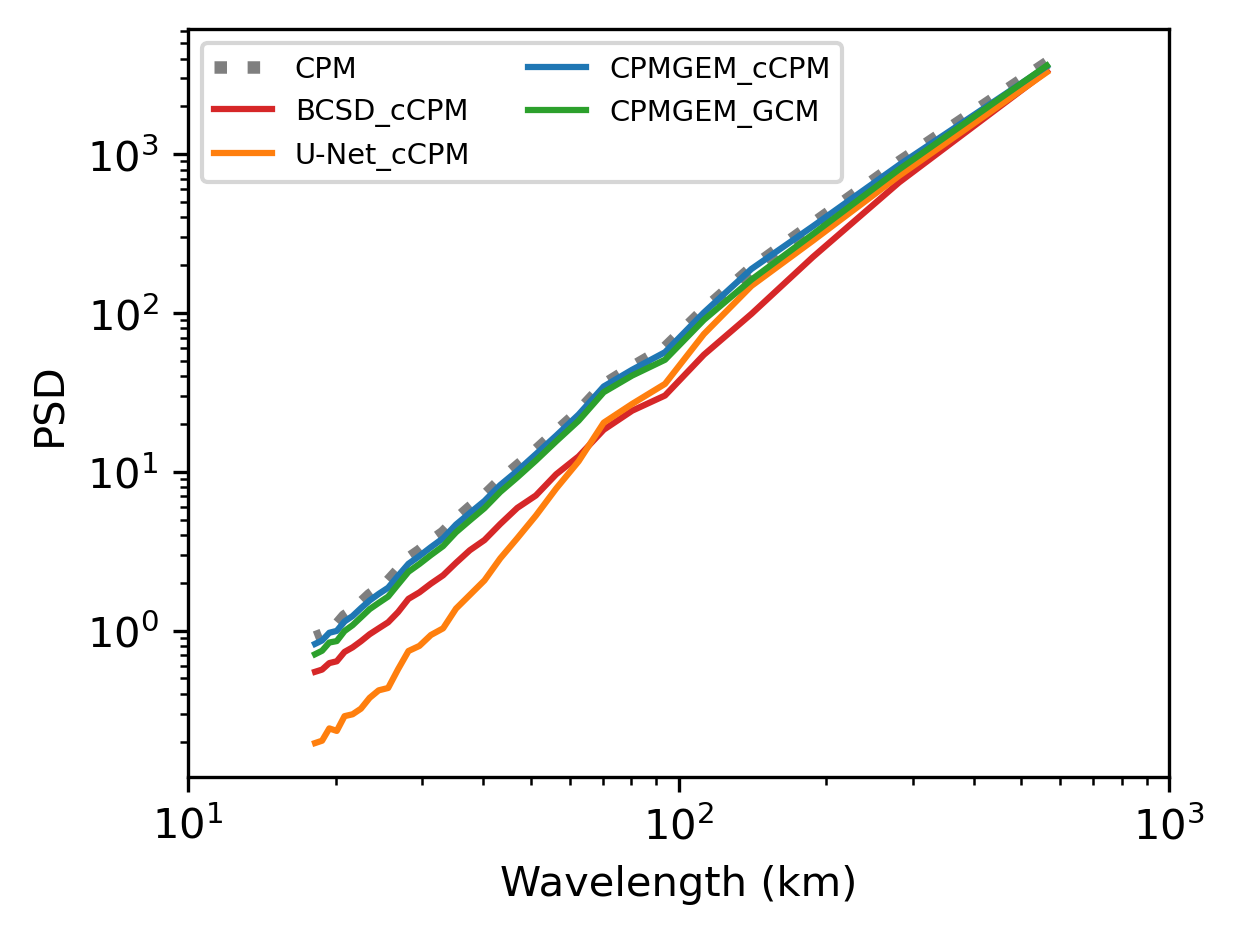

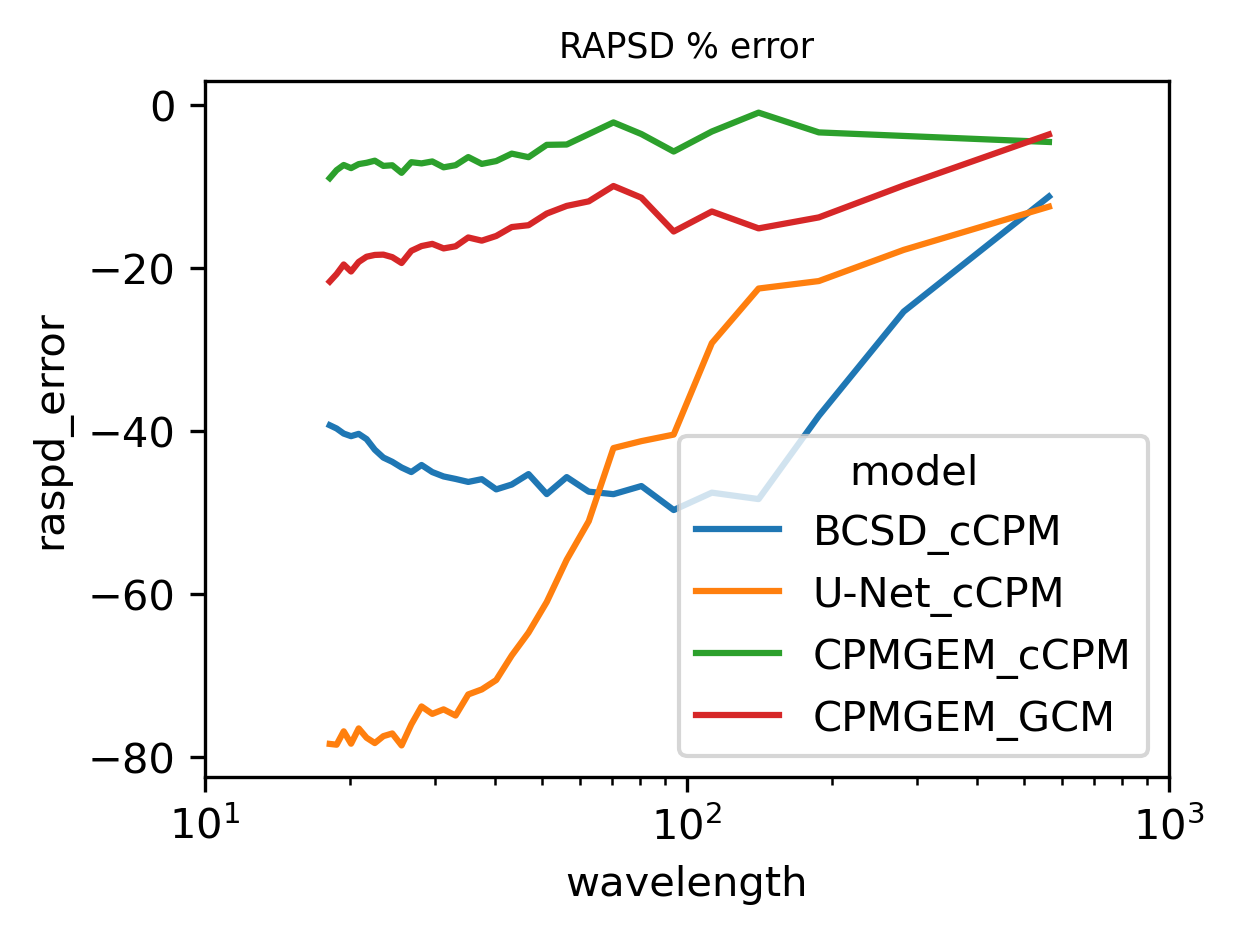

wavelength 
 raspd_error 
 
 
 freq 
 model 
   
   
 
 
 
 
 0.001776 
 BCSD_cCPM 
 563.2 
 -11.25 
 
 
 U-Net_cCPM 
 563.2 
 -12.5 
 
 
 CPMGEM_cCPM 
 563.2 
 -4.564 
 
 
 CPMGEM_GCM 
 563.2 
 -3.64 
 
 
 0.003551 
 BCSD_cCPM 
 281.6 
 -25.36 
 
 
 U-Net_cCPM 
 281.6 
 -17.8 
 
 
 CPMGEM_cCPM 
 281.6 
 -3.822 
 
 
 CPMGEM_GCM 
 281.6 
 -9.898 
 
 
 0.005327 
 BCSD_cCPM 
 187.7 
 -38.15 
 
 
 U-Net_cCPM 
 187.7 
 -21.62 
 
 
 CPMGEM_cCPM 
 187.7 
 -3.388 
 
 
 CPMGEM_GCM 
 187.7 
 -13.81 
 
 
 0.007102 
 BCSD_cCPM 
 140.8 
 -48.37 
 
 
 U-Net_cCPM 
 140.8 
 -22.54 
 
 
 CPMGEM_cCPM 
 140.8 
 -0.9651 
 
 
 CPMGEM_GCM 
 140.8 
 -15.16 
 
 
 0.008878 
 BCSD_cCPM 
 112.6 
 -47.58 
 
 
 U-Net_cCPM 
 112.6 
 -29.23 
 
 
 CPMGEM_cCPM 
 112.6 
 -3.279 
 
 
 CPMGEM_GCM 
 112.6 
 -13.09 
 
 
 0.010653 
 BCSD_cCPM 
 93.87 
 -49.71 
 
 
 U-Net_cCPM 
 93.87 
 -40.46 
 
 
 CPMGEM_cCPM 
 93.87 
 -5.735 
 
 
 CPMGEM_GCM 
 93.87 
 -15.54 
 
 
 0.012429 
 BCSD_cCPM 
 80.46 
 -46.77 
 
 
 U-Net_cCPM 
 80.46 
 -41.26 
 
 
 CPMGEM_cCPM 
 80.46 
 -3.593 
 
 
 CPMGEM_GCM 
 80.46 
 -11.4 
 
 
 0.014205 
 BCSD_cCPM 
 70.4 
 -47.76 
 
 
 U-Net_cCPM 
 70.4 
 -42.11 
 
 
 CPMGEM_cCPM 
 70.4 
 -2.164 
 
 
 CPMGEM_GCM 
 70.4 
 -9.963 
 
 
 0.015980 
 BCSD_cCPM 
 62.58 
 -47.46 
 
 
 U-Net_cCPM 
 62.58 
 -51.08 
 
 
 CPMGEM_cCPM 
 62.58 
 -3.596 
 
 
 CPMGEM_GCM 
 62.58 
 -11.84 
 
 
 0.017756 
 BCSD_cCPM 
 56.32 
 -45.67 
 
 
 U-Net_cCPM 
 56.32 
 -55.81 
 
 
 CPMGEM_cCPM 
 56.32 
 -4.875 
 
 
 CPMGEM_GCM 
 56.32 
 -12.4 
 
 
 0.019531 
 BCSD_cCPM 
 51.2 
 -47.76 
 
 
 U-Net_cCPM 
 51.2 
 -60.99 
 
 
 CPMGEM_cCPM 
 51.2 
 -4.915 
 
 
 CPMGEM_GCM 
 51.2 
 -13.34 
 
 
 0.021307 
 BCSD_cCPM 
 46.93 
 -45.3 
 
 
 U-Net_cCPM 
 46.93 
 -64.75 
 
 
 CPMGEM_cCPM 
 46.93 
 -6.429 
 
 
 CPMGEM_GCM 
 46.93 
 -14.77 
 
 
 0.023082 
 BCSD_cCPM 
 43.32 
 -46.58 
 
 
 U-Net_cCPM 
 43.32 
 -67.55 
 
 
 CPMGEM_cCPM 
 43.32 
 -5.992 
 
 
 CPMGEM_GCM 
 43.32 
 -15 
 
 
 0.024858 
 BCSD_cCPM 
 40.23 
 -47.18 
 
 
 U-Net_cCPM 
 40.23 
 -70.56 
 
 
 CPMGEM_cCPM 
 40.23 
 -6.904 
 
 
 CPMGEM_GCM 
 40.23 
 -16.09 
 
 
 0.026634 
 BCSD_cCPM 
 37.55 
 -45.92 
 
 
 U-Net_cCPM 
 37.55 
 -71.71 
 
 
 CPMGEM_cCPM 
 37.55 
 -7.253 
 
 
 CPMGEM_GCM 
 37.55 
 -16.67 
 
 
 0.028409 
 BCSD_cCPM 
 35.2 
 -46.26 
 
 
 U-Net_cCPM 
 35.2 
 -72.33 
 
 
 CPMGEM_cCPM 
 35.2 
 -6.413 
 
 
 CPMGEM_GCM 
 35.2 
 -16.28 
 
 
 0.030185 
 BCSD_cCPM 
 33.13 
 -45.9 
 
 
 U-Net_cCPM 
 33.13 
 -74.92 
 
 
 CPMGEM_cCPM 
 33.13 
 -7.412 
 
 
 CPMGEM_GCM 
 33.13 
 -17.36 
 
 
 0.031960 
 BCSD_cCPM 
 31.29 
 -45.59 
 
 
 U-Net_cCPM 
 31.29 
 -74.16 
 
 
 CPMGEM_cCPM 
 31.29 
 -7.671 
 
 
 CPMGEM_GCM 
 31.29 
 -17.62 
 
 
 0.033736 
 BCSD_cCPM 
 29.64 
 -45.05 
 
 
 U-Net_cCPM 
 29.64 
 -74.71 
 
 
 CPMGEM_cCPM 
 29.64 
 -6.95 
 
 
 CPMGEM_GCM 
 29.64 
 -17.06 
 
 
 0.035511 
 BCSD_cCPM 
 28.16 
 -44.19 
 
 
 U-Net_cCPM 
 28.16 
 -73.8 
 
 
 CPMGEM_cCPM 
 28.16 
 -7.191 
 
 
 CPMGEM_GCM 
 28.16 
 -17.33 
 
 
 0.037287 
 BCSD_cCPM 
 26.82 
 -45.05 
 
 
 U-Net_cCPM 
 26.82 
 -76.01 
 
 
 CPMGEM_cCPM 
 26.82 
 -7.042 
 
 
 CPMGEM_GCM 
 26.82 
 -17.91 
 
 
 0.039062 
 BCSD_cCPM 
 25.6 
 -44.49 
 
 
 U-Net_cCPM 
 25.6 
 -78.58 
 
 
 CPMGEM_cCPM 
 25.6 
 -8.351 
 
 
 CPMGEM_GCM 
 25.6 
 -19.41 
 
 
 0.040838 
 BCSD_cCPM 
 24.49 
 -43.79 
 
 
 U-Net_cCPM 
 24.49 
 -77.12 
 
 
 CPMGEM_cCPM 
 24.49 
 -7.42 
 
 
 CPMGEM_GCM 
 24.49 
 -18.69 
 
 
 0.042614 
 BCSD_cCPM 
 23.47 
 -43.27 
 
 
 U-Net_cCPM 
 23.47 
 -77.45 
 
 
 CPMGEM_cCPM 
 23.47 
 -7.497 
 
 
 CPMGEM_GCM 
 23.47 
 -18.38 
 
 
 0.044389 
 BCSD_cCPM 
 22.53 
 -42.31 
 
 
 U-Net_cCPM 
 22.53 
 -78.29 
 
 
 CPMGEM_cCPM 
 22.53 
 -6.858 
 
 
 CPMGEM_GCM 
 22.53 
 -18.42 
 
 
 0.046165 
 BCSD_cCPM 
 21.66 
 -41.01 
 
 
 U-Net_cCPM 
 21.66 
 -77.64 
 
 
 CPMGEM_cCPM 
 21.66 
 -7.115 
 
 
 CPMGEM_GCM 
 21.66 
 -18.64 
 
 
 0.047940 
 BCSD_cCPM 
 20.86 
 -40.37 
 
 
 U-Net_cCPM 
 20.86 
 -76.5 
 
 
 CPMGEM_cCPM 
 20.86 
 -7.279 
 
 
 CPMGEM_GCM 
 20.86 
 -19.28 
 
 

In [ ]:
# if len(eval_vars) > 1:
#     gridspec = np.pad(np.array(eval_vars), (0, -len(eval_vars) % 2), constant_values=".").reshape(-1, 1)
# else:
#     gridspec = np.array([eval_vars])
# structure_fig = plt.figure(figsize=(5.5*gridspec.shape[1], 3.5*gridspec.shape[0]), layout="constrained")
# axd = structure_fig.subplot_mosaic(gridspec, sharey=True, sharex=False)

for var in eval_vars:
    IPython.display.display_markdown(f"### {var}", raw=True)
    # gridspec = np.array([var]).reshape(1,1)
    structure_fig = plt.figure(figsize=(4, 3), layout="constrained")
    axd = structure_fig.subplot_mosaic([[var]], sharey=True, sharex=False)
    cpm_hr_rapsd = pysteps_rapsd(CPM_DAS[var].stack(example=["ensemble_member", "time"]).transpose("example", "grid_latitude", "grid_longitude"), pixel_size=8.8).mean(dim="example").drop_sel(freq=0)
    
    pred_rapsds = [
        {
            "label": model,
            "color": spec["color"],
            "data": pysteps_rapsd(EVAL_DS[source][f"pred_{var}"].sel(model=model).stack(example=["ensemble_member", "sample_id", "time"]).transpose("example", "grid_latitude", "grid_longitude"), pixel_size=8.8).mean(dim="example").drop_sel(freq=0)
        }
        for source, mconfigs in MODELS.items() for model, spec in mconfigs.items()
    ]
    
    ax = axd[var]

    plot_psd(cpm_hr_rapsd, pred_rapsds, ax=ax)
    # ax.set_title(CPM_DAS[var].attrs["long_name"])
    
    plt.show()

    rapsd_errors_da = xr.concat([ 100*(h["data"] - cpm_hr_rapsd)/cpm_hr_rapsd for h in pred_rapsds ], dim="model").rename("raspd_error").assign_coords(wavelength=(["freq"], 1/cpm_hr_rapsd["freq"].values))
    
    fig = plt.figure(figsize=(4, 3), layout="constrained")
    ax = fig.subplots(1)
    l = rapsd_errors_da.plot(x="wavelength", hue="model", ax=ax)
    ax.set_title("RAPSD % error", fontsize="small")
    ax.set_xlim(10, 1000)
    ax.set_xscale("log")
    plt.rc('legend', fontsize = "xx-small", title_fontsize="x-small")
    
    plt.show()
    
    _ = pretty_table(rapsd_errors_da, round=4, dim_order=["freq", "model"])